## Esto no es EDA real, solo queria ver correlaciones entre aglunas variables

In [2]:
import pandas as pd

data = pd.read_csv('competition_data.csv')
submission = pd.read_csv('submission.csv')
submission_aux = pd.read_csv('submission.csv')

In [3]:
data = data.drop(columns=['username', 'conn_country', 'user_agent_decrypted'])
submission = submission.drop(columns=['username', 'conn_country', 'user_agent_decrypted'])

In [4]:
# del timestamp, solo nos interesa distinguir hora, el dia de la semana, el mes y el año

data['ts'] = pd.to_datetime(data['ts'])
submission['ts'] = pd.to_datetime(submission['ts'])

# Extraer la hora
data['hour'] = data['ts'].dt.hour
submission['hour'] = submission['ts'].dt.hour

# Extraer el día de la semana (0 es lunes, 6 es domingo)
data['day_of_week'] = data['ts'].dt.dayofweek
submission['day_of_week'] = submission['ts'].dt.dayofweek

# Extraer el mes
data['month'] = data['ts'].dt.month
submission['month'] = submission['ts'].dt.month

# Extraer el año
data['year'] = data['ts'].dt.year - 2000
submission['year'] = submission['ts'].dt.year - 2000

In [5]:
# del dispositivo, solo queremos saber si se reprodujo en celular (iphone) o no
data['is_iphone'] = data['platform'].apply(lambda x: 1 if ('ios' in x or 'iOS' in x) else 0)
submission['is_iphone'] = submission['platform'].apply(lambda x: 1 if ('ios' in x or 'iOS' in x) else 0)

# dropeamos platform
data = data.drop(columns=['platform'])
submission = submission.drop(columns=['platform'])

In [6]:
data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET,hour,day_of_week,month,year,is_iphone
0,110163,2018-03-11 05:05:45+00:00,Crazy For U,Big Time Rush,24/seven,spotify:track:3jFfr89lnSmb4QBtfG8JBP,clickrow,False,False,5,6,3,18,1
1,66026,2023-06-05 10:42:33+00:00,Nada Personal - Remasterizado 2007,Soda Stereo,Me Verás Volver (Hits & Más),spotify:track:09TTeexnlKewZdjOak2sV2,trackdone,True,False,10,0,6,23,1
2,116790,2018-07-01 02:04:51+00:00,Good Times,CHIC,Risqué,spotify:track:0G3fbPbE1vGeABDEZF0jeG,trackdone,True,True,2,6,7,18,1
3,18431,2019-09-08 04:58:07+00:00,Verano del 92,Los Piojos,3er Arco,spotify:track:1NXvuBAq48QrxRFQZVmORQ,trackdone,False,True,4,6,9,19,1
4,82941,2017-07-13 18:13:52+00:00,Simpatico,Ekko Park,Simpatico,spotify:track:2gYJY0sIx1ErgTIha2nPRg,trackdone,True,False,18,3,7,17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,78756,2017-04-06 20:31:14+00:00,Losing My Religion,R.E.M.,In Time: The Best Of R.E.M. 1988-2003,spotify:track:12axV6NUqaYH3yFUWwArzr,trackdone,True,False,20,3,4,17,1
100140,12585,2021-11-03 21:06:07+00:00,Cerca De La Revolucion,Charly García,Piano Bar,spotify:track:66grIvFLGrI4tNhggO2DAd,trackdone,True,False,21,2,11,21,1
100141,93960,2022-01-14 01:13:42+00:00,A Los Jóvenes De Ayer - Remastered 2012,Serú Girán,Bicicleta,spotify:track:6YAl320SfxLO4rVIZTFKqG,trackdone,True,False,1,4,1,22,1
100142,74339,2024-05-01 17:51:16+00:00,heat not hot,Serengeti,heat not hot,spotify:track:0rKLO1hXpmoIthQgJKoczN,trackdone,True,False,17,2,5,24,1


In [7]:
correlacion = data['TARGET'].corr(data['is_iphone'])
print(f"Correlación: {correlacion:.4f}")

Correlación: -0.1861


In [8]:
# Aplicar One-Hot Encoding a razon de reproduccion
data_encoded = pd.get_dummies(data['reason_start'], prefix='reason', dummy_na=False)

# Concatenar el DataFrame original con el nuevo DataFrame de variables codificadas
data = pd.concat([data, data_encoded], axis=1)

# Dropear la columna original
data = data.drop(columns=['reason_start'])
data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,...,is_iphone,reason_appload,reason_backbtn,reason_clickrow,reason_fwdbtn,reason_playbtn,reason_remote,reason_trackdone,reason_trackerror,reason_unknown
0,110163,2018-03-11 05:05:45+00:00,Crazy For U,Big Time Rush,24/seven,spotify:track:3jFfr89lnSmb4QBtfG8JBP,False,False,5,6,...,1,False,False,True,False,False,False,False,False,False
1,66026,2023-06-05 10:42:33+00:00,Nada Personal - Remasterizado 2007,Soda Stereo,Me Verás Volver (Hits & Más),spotify:track:09TTeexnlKewZdjOak2sV2,True,False,10,0,...,1,False,False,False,False,False,False,True,False,False
2,116790,2018-07-01 02:04:51+00:00,Good Times,CHIC,Risqué,spotify:track:0G3fbPbE1vGeABDEZF0jeG,True,True,2,6,...,1,False,False,False,False,False,False,True,False,False
3,18431,2019-09-08 04:58:07+00:00,Verano del 92,Los Piojos,3er Arco,spotify:track:1NXvuBAq48QrxRFQZVmORQ,False,True,4,6,...,1,False,False,False,False,False,False,True,False,False
4,82941,2017-07-13 18:13:52+00:00,Simpatico,Ekko Park,Simpatico,spotify:track:2gYJY0sIx1ErgTIha2nPRg,True,False,18,3,...,1,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,78756,2017-04-06 20:31:14+00:00,Losing My Religion,R.E.M.,In Time: The Best Of R.E.M. 1988-2003,spotify:track:12axV6NUqaYH3yFUWwArzr,True,False,20,3,...,1,False,False,False,False,False,False,True,False,False
100140,12585,2021-11-03 21:06:07+00:00,Cerca De La Revolucion,Charly García,Piano Bar,spotify:track:66grIvFLGrI4tNhggO2DAd,True,False,21,2,...,1,False,False,False,False,False,False,True,False,False
100141,93960,2022-01-14 01:13:42+00:00,A Los Jóvenes De Ayer - Remastered 2012,Serú Girán,Bicicleta,spotify:track:6YAl320SfxLO4rVIZTFKqG,True,False,1,4,...,1,False,False,False,False,False,False,True,False,False
100142,74339,2024-05-01 17:51:16+00:00,heat not hot,Serengeti,heat not hot,spotify:track:0rKLO1hXpmoIthQgJKoczN,True,False,17,2,...,1,False,False,False,False,False,False,True,False,False


In [9]:
for col in data_encoded.columns:
    correlacion = data['TARGET'].corr(data[col])
    print(f"Correlación {col}: {correlacion:.4f}")

Correlación reason_appload: -0.0194
Correlación reason_backbtn: 0.0407
Correlación reason_clickrow: -0.0676
Correlación reason_fwdbtn: 0.3944
Correlación reason_playbtn: 0.1219
Correlación reason_remote: -0.0207
Correlación reason_trackdone: -0.4225
Correlación reason_trackerror: 0.0107
Correlación reason_unknown: -0.0318


In [10]:
for col in ['hour', 'day_of_week', 'month', 'year']:
    correlacion = data['TARGET'].corr(data[col])
    print(f"Correlación {col}: {correlacion:.4f}")

Correlación hour: 0.1421
Correlación day_of_week: 0.0133
Correlación month: 0.0430
Correlación year: 0.1624


In [11]:
data = data.sort_values(by='ts')
def calculate_fwdbtn_seguidos(df):
    # Inicializamos la columna en 0
    df['fwdbtn_seguidos'] = 0
    
    # Iteramos desde la segunda fila
    for i in range(0, len(df)):
        if data.at[i, 'reason_fwdbtn'] == 1:
            # Si la razón es 1, sumamos 1 a la columna fwdbtn_seguidos de la fila actual
            df.at[i, 'fwdbtn_seguidos'] = df.at[i-1, 'fwdbtn_seguidos'] + 1

calculate_fwdbtn_seguidos(data)

In [12]:
data['fwdbtn_seguidos'].quantile(0.9)

np.float64(2.0)

In [13]:
def calculate_fwdbtn_spree(df):
    # Inicializamos la columna en 0
    df['fwdbtn_spree'] = 0
    
    # Iteramos desde la segunda fila
    for i in range(0, len(df)):
        if data.at[i, 'fwdbtn_seguidos'] > 1:
            df.at[i, 'fwdbtn_spree'] = 1
calculate_fwdbtn_spree(data)

In [14]:
data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,...,reason_backbtn,reason_clickrow,reason_fwdbtn,reason_playbtn,reason_remote,reason_trackdone,reason_trackerror,reason_unknown,fwdbtn_seguidos,fwdbtn_spree
98291,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,True,True,18,4,...,False,False,True,False,False,False,False,False,1,0
58819,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,False,True,20,6,...,False,False,False,False,False,False,False,False,0,0
57761,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,False,True,20,6,...,False,False,True,False,False,False,False,False,1,0
62907,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,False,True,20,6,...,False,False,True,False,False,False,False,False,2,1
17525,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,False,True,21,3,...,False,False,False,False,False,False,False,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78701,74911,2024-05-23 17:24:56+00:00,The Tide Is High,Blondie,Atomic/Atomix,spotify:track:52Rp3xBJFYYdmpgzDy0Quf,True,False,17,3,...,False,False,False,False,False,True,False,False,0,0
83415,74912,2024-05-23 17:28:33+00:00,The Less I Know The Better,Tame Impala,Currents,spotify:track:6K4t31amVTZDgR3sKmwUJJ,True,False,17,3,...,False,False,False,False,False,True,False,False,0,0
99058,74913,2024-05-23 23:44:01+00:00,Pink + White,Frank Ocean,Blonde,spotify:track:3xKsf9qdS1CyvXSMEid6g8,True,False,23,3,...,False,False,False,False,False,True,False,False,0,0
1772,74914,2024-05-23 23:50:25+00:00,Still Got The Blues,Gary Moore,Still Got The Blues,spotify:track:0DnGfA1r8pAssJCuq4ojla,True,False,23,3,...,False,True,False,False,False,False,False,False,0,0


In [15]:
correlacion = data['TARGET'].corr(data['fwdbtn_spree'])
print(f"Correlación: {correlacion:.4f}")

Correlación: 0.2107


In [16]:
def calculate_trackdone_seguidos(df):
    # Inicializamos la columna en 0
    df['trackdone_seguidos'] = 0

    for i in range(0, len(df)):
        if data.at[i, 'reason_trackdone'] == 1:
            # Si la razón es 1, sumamos 1 a la columna fwdbtn_seguidos de la fila actual
            df.at[i, 'trackdone_seguidos'] = df.at[i-1, 'trackdone_seguidos'] + 1

calculate_trackdone_seguidos(data)

def calculate_fwdbtn_spree(df):
    # Inicializamos la columna en 0
    df['trackdone_spree'] = 0
    
    # Iteramos desde la segunda fila
    for i in range(0, len(df)):
        if data.at[i, 'trackdone_seguidos'] > 1:
            df.at[i, 'trackdone_spree'] = 1
calculate_fwdbtn_spree(data)

In [17]:
data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,...,reason_fwdbtn,reason_playbtn,reason_remote,reason_trackdone,reason_trackerror,reason_unknown,fwdbtn_seguidos,fwdbtn_spree,trackdone_seguidos,trackdone_spree
98291,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,True,True,18,4,...,True,False,False,False,False,False,1,0,0,0
58819,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,False,True,20,6,...,False,False,False,False,False,False,0,0,0,0
57761,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,False,True,20,6,...,True,False,False,False,False,False,1,0,0,0
62907,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,False,True,20,6,...,True,False,False,False,False,False,2,1,0,0
17525,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,False,True,21,3,...,False,False,False,False,False,False,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78701,74911,2024-05-23 17:24:56+00:00,The Tide Is High,Blondie,Atomic/Atomix,spotify:track:52Rp3xBJFYYdmpgzDy0Quf,True,False,17,3,...,False,False,False,True,False,False,0,0,2,1
83415,74912,2024-05-23 17:28:33+00:00,The Less I Know The Better,Tame Impala,Currents,spotify:track:6K4t31amVTZDgR3sKmwUJJ,True,False,17,3,...,False,False,False,True,False,False,0,0,1,0
99058,74913,2024-05-23 23:44:01+00:00,Pink + White,Frank Ocean,Blonde,spotify:track:3xKsf9qdS1CyvXSMEid6g8,True,False,23,3,...,False,False,False,True,False,False,0,0,1,0
1772,74914,2024-05-23 23:50:25+00:00,Still Got The Blues,Gary Moore,Still Got The Blues,spotify:track:0DnGfA1r8pAssJCuq4ojla,True,False,23,3,...,False,False,False,False,False,False,0,0,0,0


In [30]:
correlacion = data['TARGET'].corr(data['trackdone_spree'])
print(f"Correlación: {correlacion:.4f}")

Correlación: -0.2100


In [ ]:
data.describe()           

,Unnamed: 0,hour,day_of_week,month,year,is_iphone,fwdbtn_seguidos,fwdbtn_spree,trackdone_seguidos,trackdone_spree
count,100144.000000,100144.000000,100144.00000,100144.000000,100144.000000,100144.000000,100144.000000,100144.000000,100144.000000,100144.000000
mean,62656.589970,14.283052,3.20817,6.545854,19.758927,0.690905,0.662027,0.158402,0.491293,0.108903
std,36145.052976,7.929678,2.01999,3.346336,1.918368,0.462123,1.053908,0.365119,0.862126,0.311519
min,0.000000,0.000000,0.00000,1.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31372.500000,6.000000,1.00000,4.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,62674.500000,17.000000,3.00000,7.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,93931.250000,21.000000,5.00000,9.000000,21.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,125179.000000,23.000000,6.00000,12.000000,24.000000,1.000000,12.000000,1.000000,12.000000,1.000000


In [ ]:
data.isnull().sum()  

Unnamed: 0                             0
ts                                     0
master_metadata_track_name           973
master_metadata_album_artist_name    973
master_metadata_album_album_name     973
spotify_track_uri                    973
shuffle                                0
TARGET                                 0
hour                                   0
day_of_week                            0
month                                  0
year                                   0
is_iphone                              0
reason_appload                         0
reason_backbtn                         0
reason_clickrow                        0
reason_fwdbtn                          0
reason_playbtn                         0
reason_remote                          0
reason_trackdone                       0
reason_trackerror                      0
reason_unknown                         0
fwdbtn_seguidos                        0
fwdbtn_spree                           0
trackdone_seguid

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15)) 
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

<Figure size 1200x600 with 0 Axes>

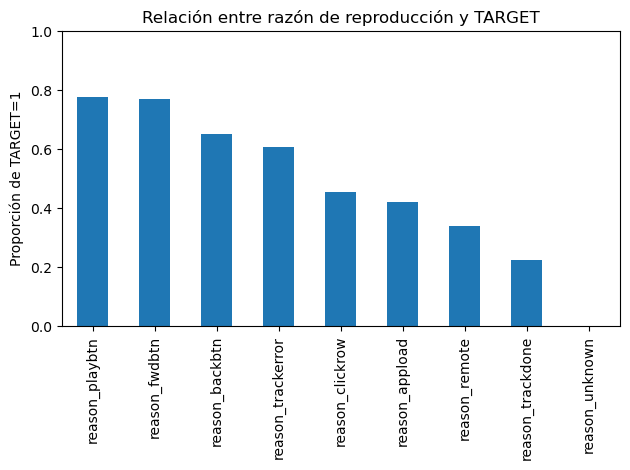

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

one_hot_cols = [col for col in data.columns if col.startswith('reason_')] 

category_target_means = {
    col: data.loc[data[col] == 1, 'TARGET'].mean()
    for col in one_hot_cols
}

mean_df = pd.DataFrame.from_dict(category_target_means, orient='index', columns=['TARGET_mean'])
mean_df = mean_df.sort_values(by='TARGET_mean', ascending=False)

plt.figure(figsize=(12,6))
mean_df.plot(kind='bar', legend=False)
plt.title('Relación entre razón de reproducción y TARGET')
plt.ylabel('Proporción de TARGET=1')
plt.xticks(rotation=90)
plt.tight_layout()
plt.ylim(0, 1)
plt.show()

<Figure size 1200x600 with 0 Axes>

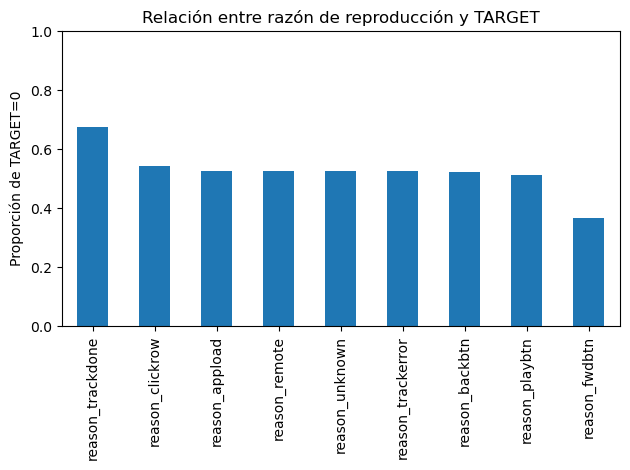

In [31]:
one_hot_cols = [col for col in data.columns if col.startswith('reason_')] 

category_target_means = {
    col: data.loc[data[col] == 0, 'TARGET'].mean()
    for col in one_hot_cols
}

mean_df = pd.DataFrame.from_dict(category_target_means, orient='index', columns=['TARGET_mean'])
mean_df = mean_df.sort_values(by='TARGET_mean', ascending=False)

plt.figure(figsize=(12,6))
mean_df.plot(kind='bar', legend=False)
plt.title('Relación entre razón de reproducción y TARGET')
plt.ylabel('Proporción de TARGET=0')
plt.xticks(rotation=90)
plt.tight_layout()
plt.ylim(0, 1)
plt.show()